In [1]:
# --- Regression of sales on Total videos (uses both sheets) ---
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.formula.api as smf

In [2]:
FILE_PATH = "TOP 2500 final.xlsx" 

In [3]:
# 1) Load both sheets and combine
xl = pd.ExcelFile(FILE_PATH)
df = pd.concat([pd.read_excel(FILE_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
df

,SKU,ASIN,TOTAL QUANTITY,Descrption,Auction Title,A & A+ Content,Classification,Rating,Review Count,Total Images,Total Videos,QUANTITY,DESCRIPTION,AUCTION TITLE,A & A+
0,11461,B00FM6BPVU,1983.0,NOVICA Artisan Crafted Hand Blown Clear Cobalt...,"Blown glass drinking glasses, 'Classic' (set o...",Not A and A+ Content,Tableware & Entertaining,4.8,958,8,2,NaN,NaN,NaN,NaN
1,83019,B0002JLL6G,1331.0,NOVICA Large Blue Hand Blown Glass Pitcher For...,"Handblown glass pitcher, 'Pure Cobalt'",Not A and A+ Content,Tableware & Entertaining,4.7,1090,8,2,NaN,NaN,NaN,NaN
2,194533,B00FPFT9X4,810.0,NOVICA Artisan Handmade Citrine .925 Sterling ...,"Pearl and citrine cluster earrings, 'Radiant L...",A+,Jewelry,4.6,640,8,1,NaN,NaN,NaN,NaN
3,420620,B0BGT49LJN,508.0,NOVICA Artisan Handmade Wooden Dala Horses | W...,"Wood ornaments, 'Dala Tradition' (set of 4)",A+,Holiday Decor & Ornaments,4.4,34,8,2,NaN,NaN,NaN,NaN
4,300838,B0855K28SZ,415.0,NOVICA Artisan Handcrafted Garnet Dangle Earri...,"Garnet dangle earrings, 'Natural Moonlight'",A+,Jewelry,4.6,667,8,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,163100,NotFound,NaN,NaN,NaN,NaN,Not Found,Not,0,0,0,1.0,NOVICA Multicolor Confetti Hand Blown Murano S...,Not Found,Not A & A+ Content
4997,123200,B000HH6LG8,NaN,NaN,NaN,NaN,Not Found,4.4,5,6,2,1.0,NOVICA Artisan Handmade Garnet Anklet Fair Tra...,"Garnet anklet, 'Scarlet'",Not A & A+ Content
4998,163154,B002C2OMS0,NaN,NaN,NaN,NaN,Jewelry,4.4,0,6,1,1.0,NOVICA Artisan Handmade Quartz Bangle Bracelet...,"Quartz bangle bracelet, 'Clarity'",Not A & A+ Content
4999,160998,B0020EPGVC,NaN,NaN,NaN,NaN,Jewelry,5.0,1,6,2,1.0,NOVICA Artisan Handmade Cultured Freshwater Pe...,"Pearl and quartz strand necklace, 'Cascade'",Not A & A+ Content


In [4]:
# 2) Standardize column names to snake_case for formulas (safer than quoting)
def snake(s): return str(s).strip().lower().replace(" ", "_").replace("+", "plus").replace("%","pct")

df.columns = [snake(c) for c in df.columns]

In [5]:
# 3) Try to detect common column names (edit if yours differ)
#    Update these to your exact names if needed.
qty_col    = next((c for c in df.columns if c in {"total_quantity","quantity","units","ordered_units","sales_volume"}), None)
videos_col = next((c for c in df.columns if c in {"total_videos","videos","video_count","#_videos"}), None)
aplus_col  = next((c for c in df.columns if c in {"a_plus_content","a+_content","aplus","a_plus"}), None)
rating_col = next((c for c in df.columns if c in {"average_rating","avg_rating","rating","star_rating"}), None)

if qty_col is None:
    raise ValueError("Could not find a quantity column (e.g., 'Total Quantity'). Please set qty_col manually.")
if videos_col is None:
    raise ValueError("Could not find a videos column (e.g., 'Total videos'). Please set videos_col manually.")

In [6]:
# 4) Clean and cast
df["qty"]    = pd.to_numeric(df[qty_col], errors="coerce").clip(lower=0)
df["videos"] = pd.to_numeric(df[videos_col], errors="coerce").fillna(0).clip(lower=0)

if aplus_col is not None:
    s = df[aplus_col].astype(str).str.strip().str.lower()
    df["aplus"] = s.map({"yes":1,"y":1,"true":1,"1":1,"present":1,"enabled":1,
                         "no":0,"n":0,"false":0,"0":0,"absent":0,"disabled":0})
    # if it was numeric already
    df["aplus"] = df["aplus"].where(~df["aplus"].isna(),
                                    pd.to_numeric(df[aplus_col], errors="coerce")).fillna(0).astype(int)
else:
    df["aplus"] = 0

if rating_col is not None:
    df["rating"] = pd.to_numeric(df[rating_col], errors="coerce")

# Keep rows with needed fields
need = ["qty","videos","aplus"] + (["rating"] if "rating" in df.columns else [])
data = df.dropna(subset=["qty","videos"]).copy()



In [7]:
# 5) Regression: log(1 + quantity) ~ videos + aplus (+ rating) + videos:aplus
data["log_qty"] = np.log1p(data["qty"])

predictors = ["videos","aplus"]
if "rating" in data.columns and not data["rating"].isna().all():
    predictors.append("rating")

# add interaction if A+ exists
if "aplus" in predictors:
    formula = "log_qty ~ videos + aplus" + (" + rating" if "rating" in predictors else "") + " + videos:aplus"
else:
    formula = "log_qty ~ videos" + (" + rating" if "rating" in predictors else "")

model = smf.ols(formula=formula, data=data).fit(cov_type="HC3")  # robust SE
print("Formula:", formula)
print(model.summary())

Formula: log_qty ~ videos + aplus + rating + videos:aplus
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     65.11
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.24e-28
Time:                        17:52:14   Log-Likelihood:                -3035.3
No. Observations:                2251   AIC:                             6077.
Df Residuals:                    2248   BIC:                             6094.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [9]:
##Statistical Test for Objective 2 

import statsmodels.api as sm
# 1) ANOVA Test 
anova_data = data.copy()

# Create video groups
anova_data['video_group'] = pd.cut(
    anova_data['videos'],
    bins=[-0.1, 0.5, 1.5, anova_data['videos'].max()],
    labels=['0_videos', '1_video', '2plus_videos']
)

# Check how many SKUs fall into each group
print(anova_data['video_group'].value_counts(dropna=False))
# One-way ANOVA: qty ~ video_group
model_anova = smf.ols('qty ~ C(video_group)', data=anova_data).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

print(anova_table)

anova_data['log_qty'] = np.log1p(anova_data['qty'])

model_anova_log = smf.ols('log_qty ~ C(video_group)', data=anova_data).fit()
anova_table_log = sm.stats.anova_lm(model_anova_log, typ=2)

print(anova_table_log)

group_stats = anova_data.groupby('video_group')['qty'].agg(['count', 'mean', 'median'])
print(group_stats)

# If you're using log_qty:
group_stats_log = anova_data.groupby('video_group')['log_qty'].mean()
print(group_stats_log) 

###Interpretation of the ANOVA 

'''Based on ANOVA, the number of videos on a product detail page has a statistically significant impact on sales across SKUs (p < 0.001).'''
'''The 2+ videos group has more high-selling SKUs pulling the mean upward.'''



video_group
1_video         1583
2plus_videos     588
0_videos         329
Name: count, dtype: int64
                      sum_sq      df          F        PR(>F)
C(video_group)  1.099229e+05     2.0  14.972728  3.436442e-07
Residual        9.165917e+06  2497.0        NaN           NaN
                     sum_sq      df          F        PR(>F)
C(video_group)   160.495586     2.0  97.714531  1.386531e-41
Residual        2050.654468  2497.0        NaN           NaN
              count       mean  median
video_group                           
0_videos        329   5.267477     4.0
1_video        1583  18.658876     8.0
2plus_videos    588  28.008503     8.0
video_group
0_videos        1.692130
1_video         2.372613
2plus_videos    2.531955
Name: log_qty, dtype: float64


/var/folders/8z/kwptk3j92371bf29wkg_mr700000gn/T/ipykernel_12416/3243486453.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = anova_data.groupby('video_group')['qty'].agg(['count', 'mean', 'median'])
/var/folders/8z/kwptk3j92371bf29wkg_mr700000gn/T/ipykernel_12416/3243486453.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats_log = anova_data.groupby('video_group')['log_qty'].mean()


'The 2+ videos group has more high-selling SKUs pulling the mean upward.'

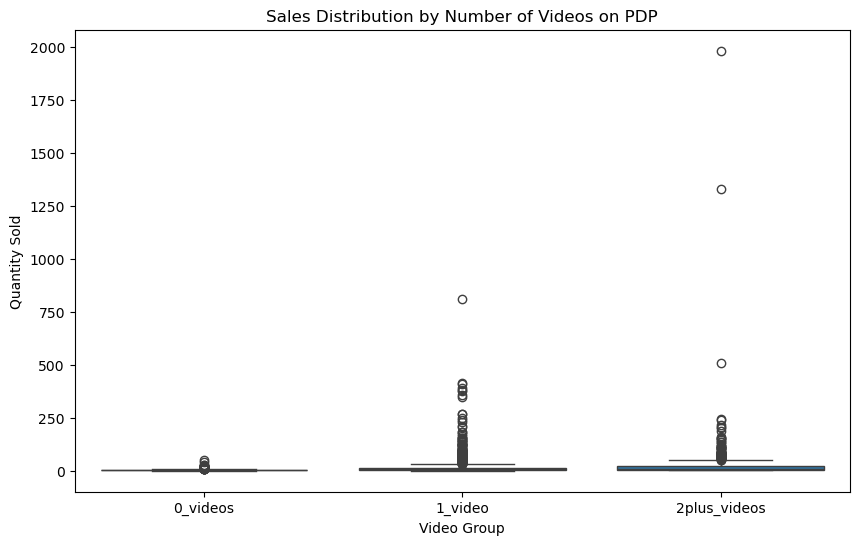

In [10]:
##Visualization to show the impact 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=anova_data,
    x='video_group',
    y='qty',
    showfliers=True,     # show outliers so you can see the spread    
)

plt.title('Sales Distribution by Number of Videos on PDP')
plt.xlabel('Video Group')
plt.ylabel('Quantity Sold')

plt.show()

##The outliers in the plot show hero products.
###The boxplot shows that products with more videos have higher sales distributions and 
###a far greater likelihood of becoming high-selling SKUs, confirming that video content 
###positively influences sales performance.

In [11]:
# 2) Mann Whitney U Test 
q25, q75 = data['qty'].quantile([0.25, 0.75])

bottom_videos = data.loc[data['qty'] <= q25, 'videos']
top_videos    = data.loc[data['qty'] >= q75, 'videos']

from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(
    top_videos,
    bottom_videos,
    alternative='two-sided'
)

print("U statistic:", u_stat)
print("p-value:", p_val)

print("Median videos (Top sellers):", top_videos.median())
print("Median videos (Bottom sellers):", bottom_videos.median())

'''Interpretation of the Mann Whitney U test''' 
#Basis the P-value and U statistic Top sellers and Bottom sellers do NOT have the same video count pattern.
#One video is standard, More than one video separates strong performers from weak ones

U statistic: 341207.5
p-value: 1.7461964816536056e-24
Median videos (Top sellers): 1.0
Median videos (Bottom sellers): 1.0


'Interpretation of the Mann Whitney U test'

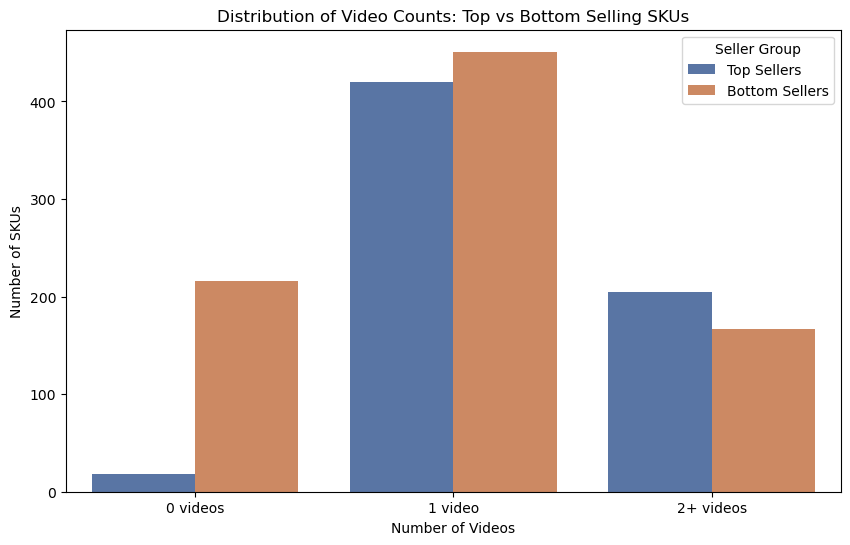

'Interpretation of the graph'

In [12]:
#Visualization for the Mann Whitney U test 
data['seller_group'] = np.where(
    data['qty'] >= q75, 'Top Sellers',
    np.where(data['qty'] <= q25, 'Bottom Sellers', 'Middle')
)

data['video_group'] = pd.cut(
    data['videos'],
    bins=[-0.1, 0.5, 1.5, data['videos'].max()],
    labels=['0 videos', '1 video', '2+ videos']
)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=data[data['seller_group'].isin(['Top Sellers', 'Bottom Sellers'])],
    x='video_group',
    hue='seller_group',
    palette='deep'   # darker, professional colors
)

plt.title('Distribution of Video Counts: Top vs Bottom Selling SKUs')
plt.xlabel('Number of Videos')
plt.ylabel('Number of SKUs')
plt.legend(title='Seller Group')

plt.show() 


'''Interpretation of the graph'''
###Bottom-selling SKUs are far more likely to have zero videos, 
###while top-selling SKUs are disproportionately represented among products 
###with two or more videos. Although both groups commonly have at least one video, 
###richer content (2+ videos) is clearly more prevalent among high performers.


In [13]:
# 3) T-test 
from scipy.stats import ttest_ind

q25, q75 = data['qty'].quantile([0.25, 0.75])

top_videos = data.loc[data['qty'] >= q75, 'videos']
bottom_videos = data.loc[data['qty'] <= q25, 'videos']

t_stat, p_val = ttest_ind(top_videos, bottom_videos, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_val)
print("Mean videos (Top Sellers):", top_videos.mean())
print("Mean videos (Bottom Sellers):", bottom_videos.mean())

mean_top = top_videos.mean()
mean_bottom = bottom_videos.mean()

percent_increase = ((mean_top - mean_bottom) / mean_bottom) * 100

print("Mean videos (Top sellers):", mean_top)
print("Mean videos (Bottom sellers):", mean_bottom)
print("Percentage increase in mean videos for Top sellers: {:.2f}%".format(percent_increase))

#Top-selling SKUs have ~37% more videos on average than bottom-selling SKUs.

T-statistic: 11.259164349729781
P-value: 2.8630407943605806e-28
Mean videos (Top Sellers): 1.2923794712286159
Mean videos (Bottom Sellers): 0.9424460431654677
Mean videos (Top sellers): 1.2923794712286159
Mean videos (Bottom sellers): 0.9424460431654677
Percentage increase in mean videos for Top sellers: 37.13%
